<a href="https://colab.research.google.com/github/ChiomaUU/CMPT2400/blob/main/Chioma_Ulom_EDA_Lab_4_(Student).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Data Encoding, Outliers & Imbalanced Data

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Seaborn is a great visualization library. You may need to install it using 'pip install seaborn'
import seaborn as sns

## Lab Activity One: Feature encoding

In this activity, you will be converting categorical text data into categorical numeric. This is done using the method called one-hot encoding. New columns are created for each category and its given binary values ($0$ or $1$) for if that entity belongs to that category or not.

In [2]:
df = pd.read_csv("Lab4_df1.csv")
df = df.drop(columns=['Unnamed: 0'])
df.head(5)

,Gender,Age,H,Mode,Q,DD,Diagnosis,R1,R3
0,female,56,5.316955,c,102.653987,-0.177034,No,0.079601,0.542921
1,female,6,4.302905,e,111.518198,5.969760,No,0.079601,0.542921
2,male,9,5.507547,f,135.896026,0.413635,Yes,0.079601,0.542921
3,male,14,6.448012,f,128.588020,-1.342695,Yes,0.079601,0.542921
4,female,77,5.525742,f,95.353828,1.536639,Yes,0.453140,9.218762


In [3]:
df.dtypes

,0
Gender,object
Age,int64
H,float64
Mode,object
Q,float64
DD,float64
Diagnosis,object
R1,float64
R3,float64


### Converting text categorical to numeric categories

The `.get_dumies()` function from pandas is extremely helpful for this. It will encode the specified categorical feature into binary values and produce new features accordingly.

##### [A] Use the `.get_dummies()` function on the `'Mode'` column to convert the values to binary values (0 and 1).

In [4]:
#One-hot encoding on 'Mode' using get_dummies()
df_encode = pd.get_dummies(df, columns=['Mode'])

#Show the first 5 rows of df_encode
df_encode.head(5)

,Gender,Age,H,Q,DD,Diagnosis,R1,R3,Mode_a,Mode_b,Mode_c,Mode_d,Mode_e,Mode_f,Mode_g,Mode_h,Mode_missing
0,female,56,5.316955,102.653987,-0.177034,No,0.079601,0.542921,False,False,True,False,False,False,False,False,False
1,female,6,4.302905,111.518198,5.969760,No,0.079601,0.542921,False,False,False,False,True,False,False,False,False
2,male,9,5.507547,135.896026,0.413635,Yes,0.079601,0.542921,False,False,False,False,False,True,False,False,False
3,male,14,6.448012,128.588020,-1.342695,Yes,0.079601,0.542921,False,False,False,False,False,True,False,False,False
4,female,77,5.525742,95.353828,1.536639,Yes,0.453140,9.218762,False,False,False,False,False,True,False,False,False


##### [A] Use the `.get_dummies()` function on the `'Gender'` column.

Note that this column already has 2 values for the feature, so it will simply assign $0$ to female and $1$ to male.

In [5]:
#One-hot encoding on 'Gender' using get_dummies()
df_encode = pd.get_dummies(df, columns=['Gender'])

#Show the first 5 rows of df_encode
df_encode.head(5)

,Age,H,Mode,Q,DD,Diagnosis,R1,R3,Gender_female,Gender_male
0,56,5.316955,c,102.653987,-0.177034,No,0.079601,0.542921,True,False
1,6,4.302905,e,111.518198,5.969760,No,0.079601,0.542921,True,False
2,9,5.507547,f,135.896026,0.413635,Yes,0.079601,0.542921,False,True
3,14,6.448012,f,128.588020,-1.342695,Yes,0.079601,0.542921,False,True
4,77,5.525742,f,95.353828,1.536639,Yes,0.453140,9.218762,True,False


##### [A] Use the `.get_dummies()` function on the `'Diagnosis'` column.

In [6]:
#One-hot encoding on Diagnosis using get_dummies()
df_encode = pd.get_dummies(df, columns=['Diagnosis'])

#Show the first 5 rows of df_encode
df_encode.head(5)

,Gender,Age,H,Mode,Q,DD,R1,R3,Diagnosis_No,Diagnosis_Yes
0,female,56,5.316955,c,102.653987,-0.177034,0.079601,0.542921,True,False
1,female,6,4.302905,e,111.518198,5.969760,0.079601,0.542921,True,False
2,male,9,5.507547,f,135.896026,0.413635,0.079601,0.542921,False,True
3,male,14,6.448012,f,128.588020,-1.342695,0.079601,0.542921,False,True
4,female,77,5.525742,f,95.353828,1.536639,0.453140,9.218762,False,True


##### [A] Observe the datatypes for your dataframe. Note that after one-hot encoding, you have int values for the transformed features.

In [7]:
#Observe df_encode datatypes
df_encode.dtypes

,0
Gender,object
Age,int64
H,float64
Mode,object
Q,float64
DD,float64
R1,float64
R3,float64
Diagnosis_No,bool
Diagnosis_Yes,bool


## Lab Activity Two: Outliers

Outliers can affect the performance of a model. Knowing the feature which contains outliers can be significantly beneficial. For example, if a dataset contains the feature 'age' of humans, then a datapoint with `age=`$150$ is an outlier. We know that this is not possible and is clearly an outlier(incorrect data entry in this case). To solve this issue, you can delete all the rows with `age >`$110$ ($110$ is a more reasonable upper limit of human age).

Another way of detecting outliers is to plot the features on a graph to visualize the data points.

In [8]:
import sklearn
import warnings
warnings.filterwarnings('ignore')


#We are loading a preinstalled dataset in the sklearn library.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
boston_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [9]:
#Observing the prepared dataframe
boston_df.head(5)


,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8


In [10]:
#Are thre any missing values?
boston_df.isnull().sum()

,0
0,0
1,0
2,0
3,506
4,506
5,506
6,506
7,506
8,506
9,506


##### [A] A boxplot organizes and splits the data into percentiles and helps to identity outliers. Using the [`seaborn`]((https://seaborn.pydata.org/generated/seaborn.boxplot.html)) library plot a boxplot of the `'2'` feature.

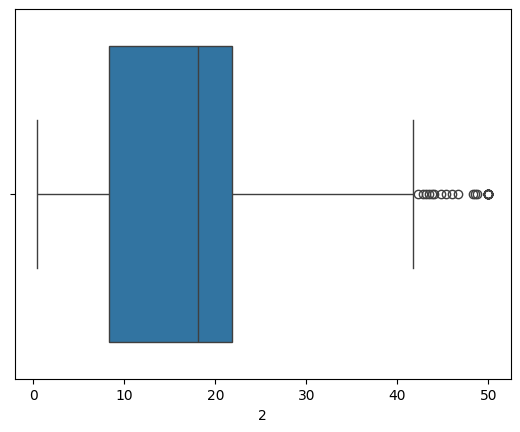

In [11]:
#boxpot for feature '2'
boxplot = sns.boxplot(x=boston_df[2])

##### [A] Briefly list and discuss some other methods that can be used to find outliers in your data

Other methods:
1.  Scatter plots: this will show outliers because they appear farther away from other more clustered dots.
2. Histogram: display data in groups and will show outliers in a bin further that other data points of a graph.
3. Interquartile Range (IQR)- The IQR method identifies outliers as points lying over 1.5 times above or below the IQR boundaries. The IQR : is calculated as IQR = Q3 − Q1.
where Q3 = third quartile = median of the upper half of the data set
Q1 = first quartile = median of the lower half of the data set
4. z-score: z-score, or standard score, shows how far away a data point is from the mean of the data. The further the z-score is from the established threshold, the more likely the data point is an outlier
5. sort data points: sorting data by ascending or descending order, then examining the data for unusually high or low points that might be outliers.


## Lab Activity Three: Imbalanced Datasets

Having an imbalanced dataset can cause affect the performance of your ML model. Below you will see examples of this problem and how you can fix it.

In [12]:
#Loading Data
df2 = pd.read_csv('creditcard.csv')
df2.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**The credit card fraud detection data is a very popular dataset used in the ML space. As you can see below the quantity of the 2 classes has a significant difference.**
- $0$ means there is no fraud
- $1$ means fraud

In [13]:
#Check the shape of data
df2.shape


(284807, 31)

In [14]:
#count the number of fraud and no fraud
df2['Class'].value_counts()

,count
Class,
0,284315
1,492


##### Visualizing this can show how a ML model will bias non-fraudulent cases.

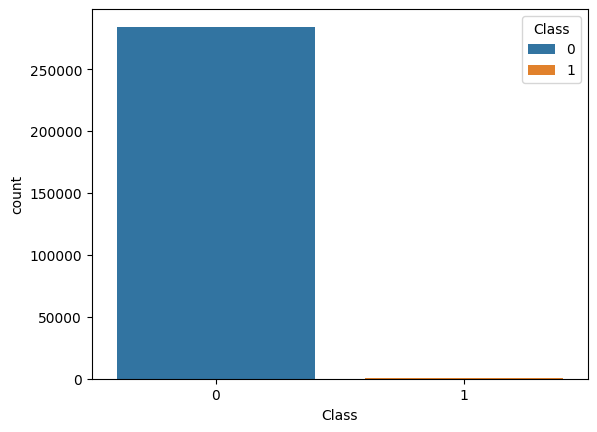

In [15]:
comparing_classes = sns.countplot(df2, x= 'Class', hue = 'Class')

##### Two ways of dealing with the imbalanced class issue would be:
1) Forcefully balance the classes. Since its a binary classification problem ($0$ or $1$) a balanced dataset would be 50% $0$ and 50% $1$.
    - **Oversampling** - *Increase* the data of the minority class.
    - **Undersampling** - *Decrease* the data of the majority class.
    
2) Use non-linear analysis approaches such as Decision Trees and/or Random Forest.

##### [A] Perform oversampling of the dataset and create a new dataframe with balanced classes (using oversampling).

In [16]:
#calculate the number of fraud and no_fraud
fraud_num = (df2['Class'] == 1).sum() #number of fraud cases
no_fraud_num = (df2['Class'] == 0).sum() #number of no fraud cases


In [17]:
#no_fraud
print('number of no-fraud cases', no_fraud_num)
#fraud
print('number of fraud cases', fraud_num)

#Show the shape of the datframes

number of no-fraud cases 284315
number of fraud cases 492


In [18]:
#Oversampling
from imblearn.over_sampling import RandomOverSampler

X = df2.drop(columns=['Class'])  #sample dataset minus imbalanced column 'Class'
y = df2['Class'] #target column 'Class'

#sampling strategy = 1 used to have ratio for fraud and no fraud cases as 50% each
df_resampled = RandomOverSampler(sampling_strategy=1 )
X_resampled, y_resampled= df_resampled.fit_resample(X, y)

#creating new dataframe with the balanced classes
new_dataframe_oversampled = pd.DataFrame(X_resampled, columns=X.columns)
new_dataframe_oversampled['Class'] = y_resampled

#Display new class distribution after random under sampling
print(y_resampled.value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [19]:
df2.shape

(284807, 31)

In [20]:
new_dataframe_oversampled.shape

(568630, 31)

##### [A] Plot a bar graph of the classes for the new oversampled dataframe.

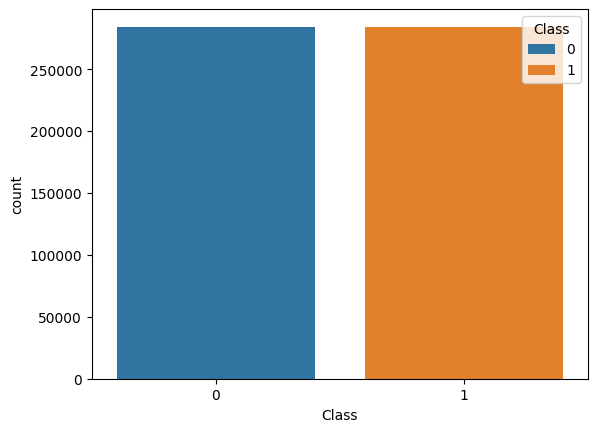

In [21]:
#Plot the bar graph for the new oversampled dataframe
bar_graph = sns.countplot(new_dataframe_oversampled, x= 'Class', hue = 'Class')

##### [A] Discuss the disadvantages of oversampling

Oversampling can cause overfitting as it duplicates the existing minority class, this could affect the model's performance with predicting new data as it tends to learn these cases.
It also increases the dataset size as seen in the case above going from 284,807 rows to 568,630, this can lead higher memory usage and longer learning times for training models, especially with large datasets.


##### [A] Perform undersampling of the `df2` dataset and create a new dataframe with balanced classes (using undersampling). Display new class counts of your new dataframe using a bar graph.

In [22]:
#Undersampling
from imblearn.under_sampling import RandomUnderSampler
X = df2.drop(columns=['Class'])  #sample dataset minus imbalanced column 'Class'
y = df2['Class'] #target Column 'Class'

#sampling strategy = 1 used to have ratio for fraud and no fraud cases as 50% each
df_resampled = RandomUnderSampler(sampling_strategy=1)
X_resampled, y_resampled= df_resampled.fit_resample(X, y)

#creating new dataframe with the balanced classes
new_dataframe_undersampled = pd.DataFrame(X_resampled, columns=X.columns)
new_dataframe_undersampled['Class'] = y_resampled

#Display new class distribution after random under sampling
print(y_resampled.value_counts())


Class
0    492
1    492
Name: count, dtype: int64


In [23]:
df2.shape

(284807, 31)

In [24]:
new_dataframe_undersampled.shape

(984, 31)

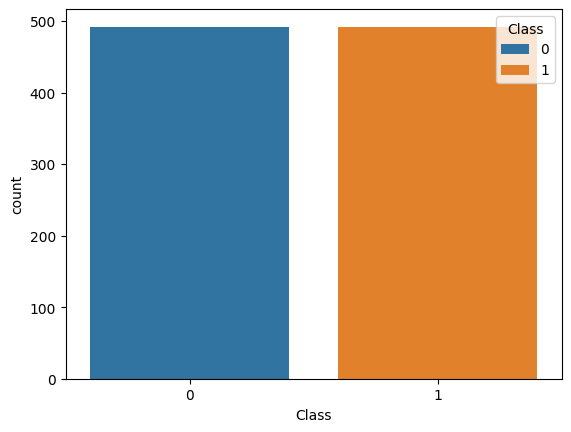

In [25]:
#Plot the bar graph for the new undersampled dataframe
bar_graph = sns.countplot(new_dataframe_undersampled, x= 'Class', hue = 'Class')

##### [A] Discuss the disadvantages of undersampling

Above, the rows decreased from 284,807 to 984 which is a drastic drop. This is a major disadvantage of undersampling, it leads to significant loss of potentially valuable information.
In addition, undersampling can cause underfitting, fewer cases of the majority class can affect model's performance with predicting new data as it tends to not learn its characteristics due to the fewer cases.